In [126]:
import numpy as np
import pandas as pd
from scipy.stats import t
from scipy.special import betaln
from scipy.special import beta as beta_func

from typing import Dict, Union, Optional

In [127]:
class BetaTEGARCH:
    """
    A unified class for Beta-Skew-t-EGARCH modeling.
    
    This class implements the Score-driven (GAS) volatility recursion and 
    the Fernandez-Steel skew-t distribution as found in the 'betategarch' package.
    """

    def __init__(
        self,
        omega: float = 0.0,
        phi1: float = 0.95,
        phi2: float = 0.0,
        kappa1: float = 0.01,
        kappa2: float = 0.0,
        kappastar: float = 0.0,
        df: float = 10.0,
        skew: float = 1.0
    ):
        self.omega = omega
        self.phi1 = phi1
        self.phi2 = phi2
        self.kappa1 = kappa1
        self.kappa2 = kappa2
        self.kappastar = kappastar
        self.df = df
        self.skew = skew  # gamma: 1.0 is symmetric, <1 left skew, >1 right skew

    def st_mean(self) -> float:
        """Calculate analytical mean of uncentred skew-t."""
        return float((self.skew - 1/self.skew) * np.sqrt(self.df) * beta_func((self.df - 1)/2, 0.5) / np.pi)

    def r_st(self, n: int, random_state: Optional[int] = None) -> np.ndarray:
        """Generate random draws from uncentred skew-t."""
        rng = np.random.default_rng(random_state)
        zstar = rng.standard_t(self.df, size=n)
        weight = self.skew / (self.skew + 1/self.skew)
        z = rng.uniform(-weight, 1 - weight, size=n)
        epsilon = np.power(self.skew, np.sign(z))
        return -np.abs(zstar) / epsilon * np.sign(z)

    def d_st(self, y: Union[float, np.ndarray], sd: float = 1.0, log: bool = False) -> Union[float, np.ndarray]:
        """PDF of uncentred skew-t (Fernandez-Steel)."""
        skew_term = np.power(self.skew, 2 * np.sign(y))
        
        if log:
            lnumerator = np.log(2) - np.log(self.skew + 1/self.skew)
            ldenom1 = betaln(0.5, self.df/2) + np.log(sd) + np.log(self.df)/2
            ldenom2 = (self.df + 1) * np.log(1 + y**2 / (skew_term * self.df * sd**2)) / 2
            return lnumerator - ldenom1 - ldenom2
        else:
            numerator = 2 / (self.skew + 1/self.skew)
            denom1 = beta_func(0.5, self.df/2) * sd * np.sqrt(self.df)
            denom2 = np.power(1 + y**2 / (skew_term * self.df * sd**2), (self.df + 1) / 2)
            return numerator / (denom1 * denom2)

    def simulate(self, T: int, burn_in: int = 200, random_state: Optional[int] = None) -> Dict[str, np.ndarray]:
        """Simulate the 1 or 2 component Score-driven volatility process."""
        total_T = T + burn_in
        y = np.zeros(total_T)
        lambda_1 = np.zeros(total_T)
        lambda_2 = np.zeros(total_T)
        
        mueps = self.st_mean()
        eps_raw = self.r_st(total_T, random_state=random_state)
        
        for t in range(1, total_T):
            ltot = self.omega + lambda_1[t-1] + lambda_2[t-1]
            sigma_t = np.exp(ltot)
            
            y[t-1] = sigma_t * (eps_raw[t-1] - mueps)
            
            # Score logic
            curr_eps = eps_raw[t-1]
            curr_eps2 = curr_eps**2
            sign_eps = np.sign(curr_eps)
            
            num = (self.df + 1) * (curr_eps2 - mueps * curr_eps)
            denom = (self.df * np.power(self.skew, 2 * sign_eps) + curr_eps2)
            u_t = (num / denom) - 1
            
            lev_term = np.sign(mueps - curr_eps) * (u_t + 1)
            
            lambda_1[t] = self.phi1 * lambda_1[t-1] + self.kappa1 * u_t
            lambda_2[t] = self.phi2 * lambda_2[t-1] + self.kappa2 * u_t + self.kappastar * lev_term

        final_lambda = self.omega + lambda_1 + lambda_2
        return {
            "y": y[burn_in:],
            "sigma": np.exp(final_lambda[burn_in:])
        }

    def build_density_matrix(self, sigma_series: np.ndarray, grid_size: int = 500) -> pd.DataFrame:
        """Construct a density matrix over a grid using simulated volatility."""
        # Create a grid based on maximum volatility to avoid 'cuts'
        max_sig = np.max(sigma_series)
        grid = np.linspace(-10 * max_sig, 10 * max_sig, grid_size)
        
        T = len(sigma_series)
        dens = np.zeros((grid_size, T))

        for t in range(T):
            # Pass sigma_series[t] to d_st (which uses self.df and self.skew)
            dens[:, t] = self.d_st(grid, sd=sigma_series[t])

        return pd.DataFrame(dens, index=grid)

# Example usage:
# model = BetaTEGARCH(phi1=0.98, kappa1=0.05, skew=0.8, df=6)
# sim = model.simulate(T=500)
# density_df = model.build_density_matrix(sim['sigma'])

<Axes: >

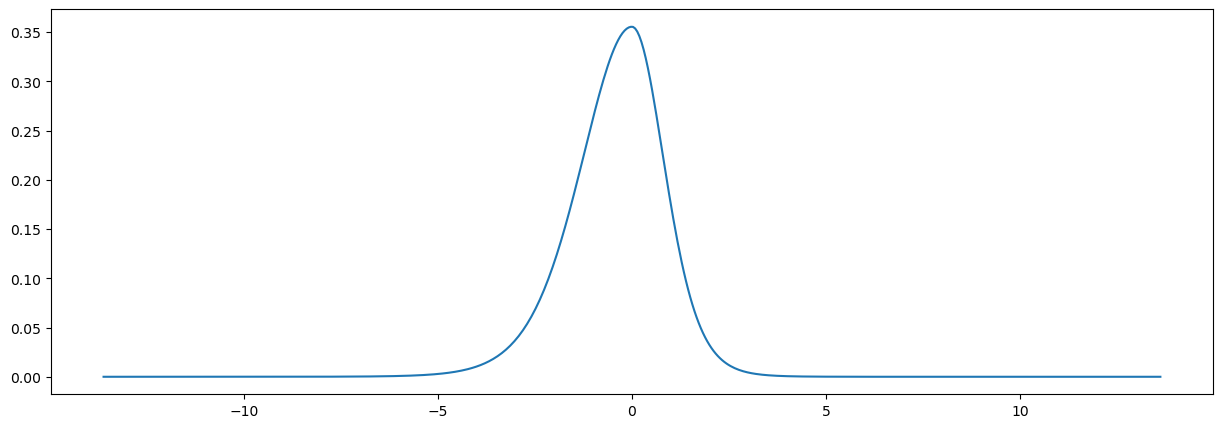

In [201]:
# Example usage:
model = BetaTEGARCH(
    omega=0.01,
    phi1=0.95,
    # phi2=0.9,
    kappa1=0.01,
    # kappa2=0.05,
    kappastar=0.05,
    df=10,
    skew=0.8)
sim = model.simulate(T=500, random_state=200)
density_df = model.build_density_matrix(sim['sigma'])

density_df.iloc[:,:1].plot(legend=False, figsize=(15,5))